<a href="https://colab.research.google.com/github/Yovezevy/2EZ4U/blob/main/Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regresi Polinomial Orde 2
Matriks persamaan normal [A | b]:
       9.00      45.00     285.00      47.50
      45.00     285.00    2025.00     325.00
     285.00    2025.00   15333.00    2438.00

Koefisien:
 a0 = 1.488095
 a1 = -0.451840
 a2 = 0.191017

syx = 0.344771
r2 = 0.994889
r = 0.997441

Persamaan: y = 1.488095 - 0.451840x + 0.191017x2

Plot disimpan ke: plot_regresi_polinomial.png


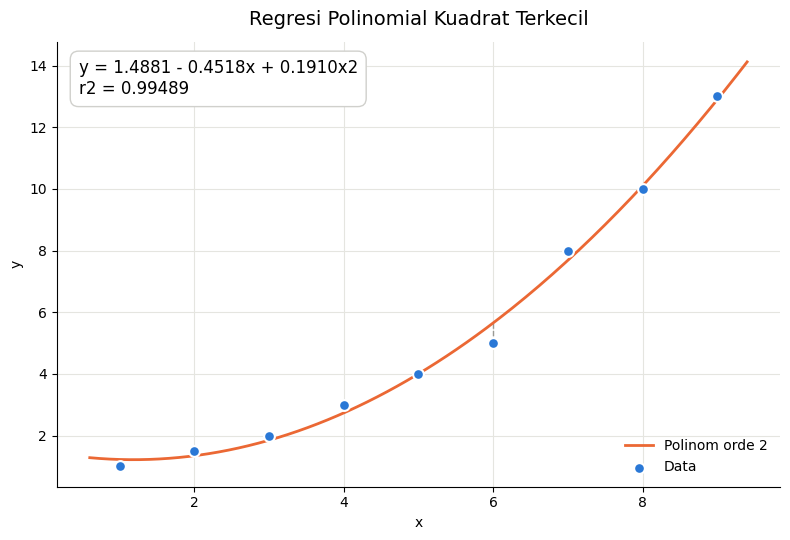

In [3]:
"""
Regresi Polinomial (Kuadrat Terkecil) + Plot
Pembentukan matriks persamaan normal diterjemahkan langsung dari
pseudocode (Chapra & Canale), lalu diselesaikan dengan Eliminasi Gauss
(pivoting parsial).

Model: y = a0 + a1*x + a2*x^2 + ... + am*x^m (m = order)
Output:
koef : [a0, a1, ..., am]
syx  : galat baku taksiran = sqrt(Sr / (n - (m + 1)))
r2   : koefisien determinasi

Kebutuhan: matplotlib (pip install matplotlib)
"""

import matplotlib.pyplot as plt

def bentuk_matriks_normal(x, y, order):
    """
    Terjemahan pseudocode. Menghasilkan matriks augmented berukuran
    (order+1) x (order+2): kolom terakhir adalah ruas kanan.
    Indeks pseudocode mulai dari 1, di Python mulai dari 0,
    jadi a[i,j] pseudocode = a[i-1][j-1] di sini.
    """
    n = len(x)
    m = order + 1
    a = [[0.0] * (m + 1) for _ in range(m)]

    for i in range(1, order + 2):
        for j in range(1, i + 1):
            k = i + j - 2
            jumlah = 0.0
            for l in range(n):
                jumlah = jumlah + x[l] ** k
            a[i - 1][j - 1] = jumlah
            a[j - 1][i - 1] = jumlah
        jumlah = 0.0
        for l in range(n):
            jumlah = jumlah + y[l] * x[l] ** (i - 1)
        a[i - 1][order + 1] = jumlah

    return a

def eliminasi_gauss(a):
    """Selesaikan matriks augmented a (ukuran m x (m+1)) dengan pivoting parsial."""
    m = len(a)
    a = [baris[:] for baris in a] # salin agar matriks asli tidak berubah

    # Eliminasi maju
    for p in range(m - 1):
        # Pivoting parsial: tukar dengan baris yang |pivot|-nya terbesar
        maks = max(range(p, m), key=lambda r: abs(a[r][p]))
        if abs(a[maks][p]) < 1e-14:
            raise ValueError("Matriks singular, sistem tidak punya solusi unik.")
        a[p], a[maks] = a[maks], a[p]

        for r in range(p + 1, m):
            faktor = a[r][p] / a[p][p]
            for c in range(p, m + 1):
                a[r][c] = a[r][c] - faktor * a[p][c]

    # Substitusi mundur
    sol = [0.0] * m
    for r in range(m - 1, -1, -1):
        jumlah = a[r][m]
        for c in range(r + 1, m):
            jumlah = jumlah - a[r][c] * sol[c]
        sol[r] = jumlah / a[r][r]

    return sol

def hitung_polinom(koef, xi):
    """Nilai polinom a0 + a1*x + ... + am*x^m di titik xi (cara Horner)."""
    hasil = 0.0
    for c in reversed(koef):
        hasil = hasil * xi + c
    return hasil

def regresi_polinomial(x, y, order):
    n = len(x)
    if n != len(y):
        raise ValueError("Panjang x dan y harus sama.")
    if n <= order + 1:
        raise ValueError(f"Butuh lebih dari {order + 1} data untuk orde {order}.")

    a = bentuk_matriks_normal(x, y, order)
    koef = eliminasi_gauss(a)

    # Galat dan koefisien determinasi
    ym = sum(y) / n
    st = 0.0
    sr = 0.0
    for i in range(n):
        st = st + (y[i] - ym) ** 2
        sr = sr + (y[i] - hitung_polinom(koef, x[i])) ** 2

    syx = (sr / (n - (order + 1))) ** 0.5
    r2 = (st - sr) / st

    return koef, syx, r2, a

def teks_persamaan(koef, desimal=4):
    """Bentuk string persamaan, misal: y = 2.4786 + 2.3593x + 1.8607x2"""
    pangkat = {2: "2", 3: "3", 4: "4", 5: "5", 6: "6", 7: "7", 8: "8", 9: "9"}
    suku = []
    for p, c in enumerate(koef):
        if p == 0:
            s = f"{abs(c):.{desimal}f}"
        elif p == 1:
            s = f"{abs(c):.{desimal}f}x"
        else:
            s = f"{abs(c):.{desimal}f}x{pangkat.get(p, '^' + str(p))}"
        suku.append(("-" if c < 0 else "+", s))

    teks = ("-" if suku[0][0] == "-" else "") + suku[0][1]
    for tanda, s in suku[1:]:
        teks += f" {tanda} {s}"
    return "y = " + teks

def plot_regresi(x, y, koef, r2, nama_file="plot_regresi_polinomial.png"):
    """Plot titik data, kurva polinom, dan residual."""
    WARNA_DATA = "#2a78d6" # biru
    WARNA_KURVA = "#eb6834" # oranye
    WARNA_RESIDU = "#9a9a94" # abu-abu

    # Titik-titik halus untuk menggambar kurva
    rentang = max(x) - min(x)
    x_awal = min(x) - 0.05 * rentang
    x_akhir = max(x) + 0.05 * rentang
    jumlah_titik = 200
    x_kurva = [x_awal + (x_akhir - x_awal) * t / (jumlah_titik - 1)
               for t in range(jumlah_titik)]
    y_kurva = [hitung_polinom(koef, xi) for xi in x_kurva]

    fig, ax = plt.subplots(figsize=(8, 5.5))

    for i in range(len(x)):
        ax.plot([x[i], x[i]], [y[i], hitung_polinom(koef, x[i])],
                color=WARNA_RESIDU, linewidth=1, linestyle="--", zorder=1)

    order = len(koef) - 1
    ax.plot(x_kurva, y_kurva, color=WARNA_KURVA, linewidth=2,
            label=f"Polinom orde {order}", zorder=2)
    ax.scatter(x, y, s=60, color=WARNA_DATA, edgecolor="white",
               linewidth=1.5, label="Data", zorder=3)

    ax.text(0.03, 0.96, f"{teks_persamaan(koef)}\nr2 = {r2:.5f}",
            transform=ax.transAxes, fontsize=12, verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                      edgecolor="#d0d0cc"))

    ax.set_title("Regresi Polinomial Kuadrat Terkecil", fontsize=14, pad=12)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, color="#e5e5e0", linewidth=0.8)
    ax.set_axisbelow(True)
    for sisi in ("top", "right"):
        ax.spines[sisi].set_visible(False)
    ax.legend(loc="lower right", frameon=False)

    fig.tight_layout()
    fig.savefig(nama_file, dpi=150)
    print(f"\nPlot disimpan ke: {nama_file}")
    plt.show()

# ==========================================
# Data dari Gambar: Latihan 2 (Regresi Linear & Polinomial)
# ==========================================
x = [1, 2, 3, 4, 5, 6, 7, 8, 9]
y = [1, 1.5, 2, 3, 4, 5, 8, 10, 13]
order = 2 # Set ke 2 untuk parabola (polinomial orde 2)

koef, syx, r2, a = regresi_polinomial(x, y, order)

print(f"Regresi Polinomial Orde {order}")
print("=" * 45)
print("Matriks persamaan normal [A | b]:")
for baris in a:
    print(" " + " ".join(f"{v:10.2f}" for v in baris))

print("\nKoefisien:")
for p, c in enumerate(koef):
    print(f" a{p} = {c:.6f}")

print(f"\nsyx = {syx:.6f}")
print(f"r2 = {r2:.6f}")
print(f"r = {r2 ** 0.5:.6f}")
print(f"\nPersamaan: {teks_persamaan(koef, 6)}")

plot_regresi(x, y, koef, r2)